In [38]:
# ===============================
# Import Required Libraries
# ===============================

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Regression algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Model evaluation metrics
from sklearn.metrics import (
mean_squared_error,
mean_absolute_error,
r2_score
)

# Statistical analysis
from scipy import stats

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

#Improve the Appearance of Graphs
# Set visualization style
plt.style.use("seaborn-v0_8-darkgrid")

# Set default color palette
sns.set_palette("husl")

In [39]:
# ============================================
# Load California Housing Dataset
# ============================================

try:

 url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"

 df = pd.read_csv(url)
 print("Dataset loaded successfully from URL!")

except:

 print("URL download failed.")
 print("Generating synthetic dataset...")

 np.random.seed(42)

 n_samples = 5000

 df = pd.DataFrame({
  "longitude": np.random.uniform(-124.5, -114.5, n_samples),

  "latitude": np.random.uniform(32.5, 42.0, n_samples),

  "housing_median_age": np.random.randint(1, 52, n_samples),

  "total_rooms": np.random.normal(2000, 1000, n_samples).astype(int),
  "total_bedrooms": np.random.normal(500, 250, n_samples).astype(int),
  "population": np.random.normal(1200, 800, n_samples).astype(int),
  "households": np.random.normal(450, 250, n_samples).astype(int),
  "median_income": np.random.uniform(0.5, 15, n_samples),
  "median_house_value": np.random.normal(200000, 80000, n_samples).astype(int),
  "ocean_proximity": 
     np.random.choice(
         [
             "NEAR BAY",
             "<1H OCEAN",
             "INLAND",
             "NEAR OCEAN",
             "ISLAND"
         ],
         n_samples,
         p=[0.30, 0.30, 0.30, 0.09, 0.01]
     )
})

# Create a relationship between features and house price
 df["median_house_value"] = (

 df["median_income"] * 40000 +

 df["housing_median_age"] * 1000 +
 df["total_rooms"] * 20 +

 np.random.normal(0, 30000, n_samples)

 ).astype(int)

# Limit house values to realistic values
 df["median_house_value"] = df["median_house_value"].clip(
     lower=50000,
     upper=500001
)

 print("Synthetic dataset created successfully!")

Dataset loaded successfully from URL!


In [40]:
#shape of the dataset
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (20640, 10)


In [41]:
#the First Five Rows
print("First Five Rows:")
df.head()

First Five Rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [42]:
print("Dataset Information")
print("-" * 50)

df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [43]:
#Statistical Summary
print("Statistical Summary")
print("-" * 50)

df.describe()

Statistical Summary
--------------------------------------------------


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [44]:
print("Missing Values")
print("-" * 50)

print(df.isnull().sum())

Missing Values
--------------------------------------------------
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [45]:
if df.isnull().sum().sum() > 0:
    print("Removing rows with missing values...")
    df = df.dropna()
    print(f"New Dataset Shape: {df.shape}")

Removing rows with missing values...
New Dataset Shape: (20433, 10)


In [ ]:
Univariate Linear Regression we use only Median Income to predict Median House Value

In [46]:
# step 1 - Select Features
x= df[['median_income']]  # independent variable
y= df['median_house_value']  # target variable

#Step 2: Split the Dataset - 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(
x,
y,
test_size=0.20,
random_state=42
)

#Step 3: Train the Model
model = LinearRegression() # creating the model
model.fit(x_train, y_train) # fit() -learns the best straight line y= b1x + b0

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
# Step 4: View the Equation
intercept = model.intercept_
coefficient = model.coef_[0]

print(f"Intercept : {intercept:.2f}")
print(f"Coefficient : {coefficient:.2f}")
print ("Therefore, HouseValue = 45035.23 + 41751.96 × MedianIncome") 
print ("For every one-unit increase in Median Income,the predicted house value increases by approximately $41,752.")

Intercept : 45035.23
Coefficient : 41751.96
Therefore, HouseValue = 45035.23 + 41751.96 × MedianIncome
For every one-unit increase in Median Income,the predicted house value increases by approximately $41,752.


In [48]:
# Step 5: Make Predictions
train_predictions = model.predict(x_train)
test_predictions = model.predict(x_test)

# Step 6: Evaluate the Model
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print ("The closer predictions are to actual values, the lower the RMSE.")
print(f'Training RMSE = {train_rmse}')
print(f'Testing RMSE = {test_rmse}')
print ("\nR2 measures how much variation in house prices is explained by the model.")
print(f'Training R2 = {train_r2}')
print(f'Testing R2 = {test_r2}')
print ("\nThe model explains about 47% of the variation in house prices using only Median Income.")

The closer predictions are to actual values, the lower the RMSE.
Training RMSE = 83418.33258032388
Testing RMSE = 84976.53325615863

R2 measures how much variation in house prices is explained by the model.
Training R2 = 0.47430066366395784
Testing R2 = 0.4719622857489497

The model explains about 47% of the variation in house prices using only Median Income.


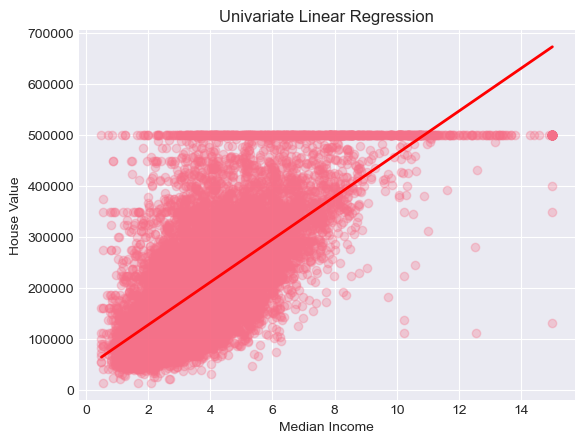

In [65]:
#Step 7: Plot the Regression Line

plt.scatter(x_train, y_train, alpha=0.3)

x_sorted = x_train.sort_values("median_income")
y_sorted = model.predict(x_sorted)

plt.plot(
x_sorted,
y_sorted,
color="red",
linewidth=2
)

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Univariate Linear Regression")
plt.show()

In [49]:
# 5. Multivariate Linear Regression
# step 1 : Machine learning models only understand numbers. so we must have to change text contained columns to numbers

encoder = LabelEncoder()
df["ocean_proximity_encoded"] = encoder.fit_transform(
df["ocean_proximity"]
)

In [50]:
# Step 2: Select Features
features = [
"median_income",
"housing_median_age",
"total_rooms",
"total_bedrooms",
"population",
"households",
"latitude",
"longitude",
"ocean_proximity_encoded"
]

x = df[features]
y = df["median_house_value"]

# Step 3: Split the Dataset
x_mtrain, x_mtest, y_mtrain, y_mtest = train_test_split(
x,
y,
test_size=0.20,
random_state=42
)

In [51]:
# Step 4: Standardize Features that have different scales b/c large numbers dominate smaller ones making every featue approximately mean= 0 and STD= 1
scaler = StandardScaler()
x_mtrain = scaler.fit_transform(x_mtrain)
x_mtest = scaler.transform(x_mtest)

# Step 5: Train the Model
model = LinearRegression()
model.fit(x_mtrain, y_mtrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
# Step 6: Display Feature Importance
coefficients = pd.DataFrame({
"Feature": features,
"Coefficient": model.coef_
})

coefficients["Absolute"] = coefficients["Coefficient"].abs()

coefficients.sort_values(
"Absolute",
ascending=False,
inplace=True
)

print(coefficients)

                   Feature   Coefficient      Absolute
6                 latitude -90748.672846  90748.672846
7                longitude -85786.969310  85786.969310
0            median_income  76403.230167  76403.230167
3           total_bedrooms  48408.769307  48408.769307
4               population -41646.359364  41646.359364
2              total_rooms -18030.456130  18030.456130
5               households  15673.527815  15673.527815
1       housing_median_age  14548.787247  14548.787247
8  ocean_proximity_encoded   -561.222239    561.222239


In [53]:
# Step 7: Make Predictions
train_predictions = model.predict(x_mtrain)
test_predictions = model.predict(x_mtest)

# Step 8: Evaluate the Model
train_rmse_multi = np.sqrt(
mean_squared_error(y_mtrain, train_predictions)
)

test_rmse_multi = np.sqrt(
mean_squared_error(y_mtest, test_predictions)
)

train_r2_multi = r2_score(y_mtrain, train_predictions)

test_r2_multi = r2_score(y_mtest, test_predictions)

print(f'Training RMSE = {train_rmse_multi}')
print(f'Testing RMSE = {test_rmse_multi}')
print(f'Training R2 = {train_r2_multi}')
print(f'Testing R2 = {test_r2_multi}')

Training RMSE = 69409.6962582108
Testing RMSE = 70171.99539639697
Training R2 = 0.636039119275638
Testing R2 = 0.6399236679243399


In [ ]:
comparison

In [54]:
comparison = pd.DataFrame({
"Model": [
"Univariate (Median Income)",
"Multivariate (All Features)"
],
"Train RMSE": [train_rmse, train_rmse_multi],
"Test RMSE": [test_rmse, test_rmse_multi],
"Train R²": [train_r2, train_r2_multi],
"Test R²": [test_r2, test_r2_multi]
})
print("Model Performance Comparison")
print(comparison.round(2))

Model Performance Comparison
                         Model  Train RMSE  Test RMSE  Train R²  Test R²
0   Univariate (Median Income)    83418.33   84976.53      0.47     0.47
1  Multivariate (All Features)    69409.70   70172.00      0.64     0.64


In [ ]:
Interpretation
The multivariate model clearly performs better.
    Using multiple features significantly improves prediction accuracy

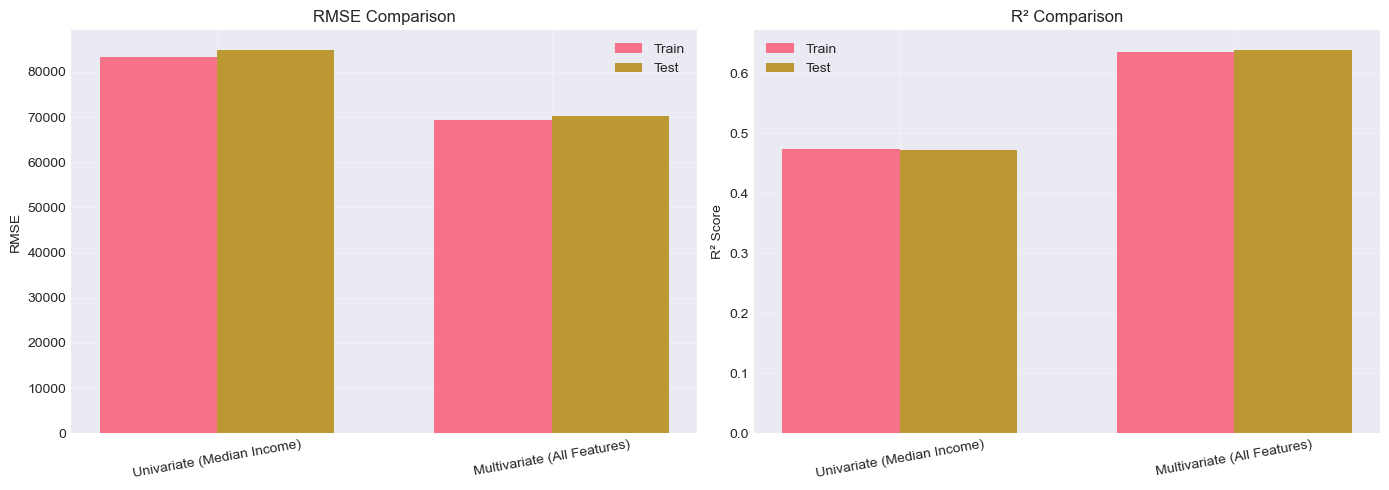

In [55]:
# Visual Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = comparison["Model"]
x = np.arange(len(models))
width = 0.35
# -----------------------------
# RMSE Comparison
# -----------------------------
axes[0].bar(
    x - width/2,
    comparison["Train RMSE"],
    width,
    label="Train"
)
axes[0].bar(
    x + width/2,
    comparison["Test RMSE"],
    width,
    label="Test"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=10)
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE Comparison")
axes[0].legend()
axes[0].grid(alpha=0.3)
# -----------------------------
# R² Comparison
# -----------------------------
axes[1].bar(
    x - width/2,
    comparison["Train R²"],
    width,
    label="Train"
)
axes[1].bar(
    x + width/2,
    comparison["Test R²"],
    width,
    label="Test"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=10)
axes[1].set_ylabel("R² Score")
axes[1].set_title("R² Comparison")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
Interpreting the Charts
RMSE Chart
The shorter the bars, the better.
The multivariate model has noticeably lower RMSE on both the training and testing datasets,
indicating more accurate predictions.
R² Chart
The taller the bars, the better.
The multivariate model achieves a much higher R² score, meaning it captures more of the
relationship between the input variables and house prices.